## <font color='blue'>Projeto Ponta a Ponta - Construindo um Modelo com TensorFlow (STL10)</font>

**Pipeline de um Projeto de IA:**
Dados → Pré-processamento → Modelo → Avaliação → Deploy

*O valor não está no dataset — está na capacidade de aplicar o mesmo pipeline em diferentes problemas!*

Neste projeto, vamos construir um modelo de Inteligência Artificial capaz de classificar imagens do dataset STL10.
O STL10 é um dataset de classificação de imagens com 10 categorias, semelhante ao CIFAR-10, mas com imagens maiores
e maior desafio para generalização do modelo.

Ao final deste projeto, você será capaz de:
- Carregar e explorar o dataset STL10
- Pré-processar imagens para treinamento
- Construir uma CNN com TensorFlow/Keras
- Avaliar o desempenho do modelo
- Testar o modelo com novas imagens

In [ ]:
# Versão da Linguagem Python
from platform import python_version
print('Versão do Python neste Notebook:', python_version())

Versão do Python neste Notebook: 3.12.13


In [ ]:
# Instala TensorFlow e TensorFlow Datasets
!pip install -q tensorflow tensorflow-datasets

In [ ]:
# Silencia mensagens do TF
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [ ]:
# Imports principais
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from PIL import Image
from io import BytesIO
from google.colab import files
import requests

## <font color='blue'>Carregando os dados - matéria prima</font>

O STL10 é um dataset de classificação de imagens com 10 classes.
Ele é semelhante ao CIFAR-10, porém utiliza imagens maiores (96x96),
o que torna o problema mais desafiador e interessante para redes convolucionais.

In [ ]:
# Carrega o dataset STL10
(ds_treino, ds_teste), info = tfds.load(
    'stl10',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.J39ZH9_1.0.0/stl10-test.tfrecord*...:   0%|          | 0/…

Generating unlabelled examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.J39ZH9_1.0.0/stl10-unlabelled.tfrecord*...:   0%|        …

Dataset stl10 downloaded and prepared to /root/tensorflow_datasets/stl10/1.0.0. Subsequent calls will reuse this data.


In [ ]:
# Exibe informações básicas
print("Número de classes:", info.features["label"].num_classes)
print("Classes originais:", info.features["label"].names)
print("Formato da imagem:", info.features["image"].shape)

Número de classes: 10
Classes originais: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Formato da imagem: (96, 96, 3)


## <font color='blue'>Tradução das classes para português brasileiro</font>

O dataset STL10 possui os nomes das categorias em inglês.  
Para tornar o projeto mais acessível e facilitar a interpretação dos resultados,  
vamos traduzir essas classes para português brasileiro.

A tradução mantém a mesma ordem das classes originais, garantindo que os índices
continuem corretos durante o treinamento e a predição.

In [ ]:
# Classes originais do dataset (em inglês)
nomes_classes_en = info.features["label"].names

# Dicionário de tradução para português brasileiro
traducao_classes = {
    'airplane': 'avião',
    'bird': 'pássaro',
    'car': 'carro',
    'cat': 'gato',
    'deer': 'veado',
    'dog': 'cachorro',
    'horse': 'cavalo',
    'monkey': 'macaco',
    'ship': 'navio',
    'truck': 'caminhão'
}

# Cria lista com nomes traduzidos mantendo a ordem do dataset
nomes_classes = [traducao_classes[nome] for nome in nomes_classes_en]

# Exibe resultado
print("Classes originais:", nomes_classes_en)
print("Classes traduzidas:", nomes_classes)

Classes originais: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Classes traduzidas: ['avião', 'pássaro', 'carro', 'gato', 'veado', 'cachorro', 'cavalo', 'macaco', 'navio', 'caminhão']


In [ ]:
# Informações do dataset
print("Número de classes:", info.features["label"].num_classes)
print("Nomes das classes:", nomes_classes)
print("Formato da imagem:", info.features["image"].shape)

Número de classes: 10
Nomes das classes: ['avião', 'pássaro', 'carro', 'gato', 'veado', 'cachorro', 'cavalo', 'macaco', 'navio', 'caminhão']
Formato da imagem: (96, 96, 3)


## <font color='blue'>Aumento artificial de dados (Data Augmentation)</font>

Uma forma de reduzir o overfitting é criar pequenas variações artificiais nas imagens de treino.

Essas transformações ajudam o modelo a enxergar diferentes versões da mesma classe,
melhorando sua capacidade de generalização.

Neste projeto, serão aplicadas transformações leves como:
- inversão horizontal
- pequena rotação
- pequeno zoom

Essas alterações são feitas apenas no conjunto de treino.

In [ ]:
# Camada de aumento artificial de dados
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

## <font color='blue'>Visualização das imagens</font>

Antes de treinar o modelo, vamos visualizar algumas imagens para entender
como os dados estão organizados e verificar se os rótulos fazem sentido.

In [ ]:
# Função para exibir imagens com os rótulos traduzidos
def visualiza_imagens(dataset, nomes_classes):
    plt.figure(figsize=(10, 10))

    for i, (imagem, label) in enumerate(dataset.take(25)):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(imagem)

        # Usa os nomes traduzidos em português
        plt.xlabel(nomes_classes[label.numpy()])

    plt.tight_layout()
    plt.show()

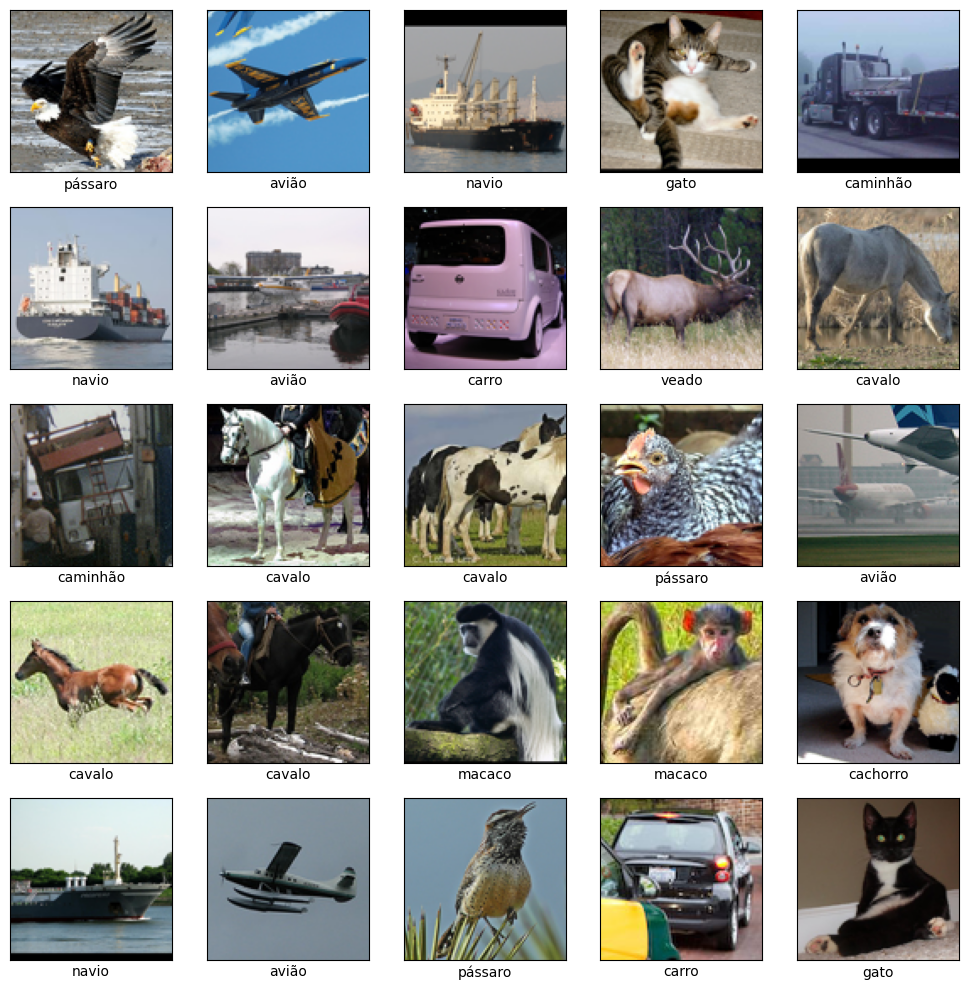

In [ ]:
# Executa a função
visualiza_imagens(ds_treino, nomes_classes)

## <font color='blue'>Pré-processamento com separação entre treino e teste</font>

No conjunto de treino, além da normalização, aplicamos aumento artificial de dados.
Já no conjunto de teste, aplicamos apenas a normalização.

Isso é importante porque o modelo deve ser treinado com maior variedade,
mas avaliado em dados reais sem alterações artificiais.

In [ ]:
# Pré-processamento para o conjunto de treino
def preprocessar_treino(imagem, label):
    # Converte para float32 e normaliza
    imagem = tf.cast(imagem, tf.float32) / 255.0

    # Aplica aumento artificial de dados somente no treino
    imagem = data_augmentation(imagem)

    return imagem, label

# Pré-processamento para o conjunto de teste
def preprocessar_teste(imagem, label):
    # Apenas normaliza os pixels
    imagem = tf.cast(imagem, tf.float32) / 255.0
    return imagem, label

# Tamanho dos lotes
batch_size = 32

# Pipeline do treino
ds_treino = ds_treino.map(preprocessar_treino).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Pipeline do teste
ds_teste = ds_teste.map(preprocessar_teste).batch(batch_size).prefetch(tf.data.AUTOTUNE)

## <font color='blue'>Construção do Modelo</font>

Arquitetura do Modelo -> Feature Learning

Como estamos trabalhando com imagens, utilizaremos uma Rede Neural Convolucional (CNN),
que é especialmente adequada para extrair padrões visuais como bordas, formas e texturas.

In [ ]:
# Criação do modelo sequencial
modelo_lia = models.Sequential()

# Camada de entrada
modelo_lia.add(layers.Input(shape=(96, 96, 3)))

# Bloco convolucional 1
modelo_lia.add(layers.Conv2D(32, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))

# Bloco convolucional 2
modelo_lia.add(layers.Conv2D(64, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))

# Bloco convolucional 3
modelo_lia.add(layers.Conv2D(128, (3, 3), activation='relu'))
modelo_lia.add(layers.MaxPooling2D((2, 2)))

In [ ]:
# Dropout: desativa parte dos neurônios durante o treino para reduzir overfitting.
# Dropout após parte convolucional
modelo_lia.add(layers.Dropout(0.3))

# Camadas densas
modelo_lia.add(layers.Flatten())
modelo_lia.add(layers.Dense(128, activation='relu'))

# Dropout antes da camada final
modelo_lia.add(layers.Dropout(0.5))

# Camada de saída
modelo_lia.add(layers.Dense(10, activation='softmax'))

In [ ]:
# Sumário do modelo
modelo_lia.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,733,066 (6.61 MB)

 Trainable params: 1,733,066 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

## <font color='blue'>Compilação do modelo</font>

Nesta etapa, definimos:
- o otimizador
- a função de erro
- a métrica de avaliação

Como este é um problema de classificação multiclasse, utilizaremos `accuracy`.

In [ ]:
# Compilação do modelo
modelo_lia.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# adam: algoritmo de otimização
# loss: função de erro para classificação multiclasse
# metrics: accuracy mede a taxa de acerto do modelo

## <font color='blue'>Treinamento com parada automática</font>

Mesmo definindo um número máximo de épocas, o treinamento será interrompido automaticamente
caso o modelo pare de melhorar na validação.

Isso evita desperdício de tempo e ajuda a preservar os melhores pesos encontrados.

In [ ]:
# EarlyStopping: interrompe o treinamento quando a val_loss para de melhorar
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Treinamento do modelo
history = modelo_lia.fit(
    ds_treino,
    epochs=40,
    validation_data=ds_teste,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 141ms/step - accuracy: 0.2500 - loss: 1.9807 - val_accuracy: 0.3762 - val_loss: 1.6469
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - accuracy: 0.3284 - loss: 1.7788 - val_accuracy: 0.4180 - val_loss: 1.5655
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 121ms/step - accuracy: 0.3724 - loss: 1.6558 - val_accuracy: 0.4423 - val_loss: 1.5070
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - accuracy: 0.4008 - loss: 1.5753 - val_accuracy: 0.4669 - val_loss: 1.4272
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 111ms/step - accuracy: 0.4172 - loss: 1.5574 - val_accuracy: 0.4595 - val_loss: 1.4175
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.4350 - loss: 1.4924 - val_accuracy: 0.5055 - val_loss: 1.3458
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 121ms/step - accuracy: 0.4562 - loss: 1.4527 - val_accuracy: 0.5024 - val_loss: 1.3497
Epoch 8/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.4770 - loss: 1

## <font color='blue'>Interpretação esperada após as correções</font>

Com as técnicas de regularização aplicadas, espera-se que:

- a loss de treino continue diminuindo
- a loss de validação deixe de crescer tão rapidamente
- a diferença entre treino e validação fique menor
- o modelo generalize melhor para imagens não vistas

vale lembrar que antes dos ajustes de aumento artificial de dados a acurácia ficava em torno de 50%, depois como é visto aumentou considerávelmente.

## <font color='blue'>Avaliação do modelo</font>

Agora vamos medir o desempenho do modelo no conjunto de teste.  
A principal métrica utilizada será a acurácia.

In [ ]:
# Avalia o modelo no conjunto de teste
erro_teste, acc_teste = modelo_lia.evaluate(ds_teste, verbose=2)

print('\nAcurácia com dados de Teste:', acc_teste)

250/250 - 4s - 14ms/step - accuracy: 0.6001 - loss: 1.0989

Acurácia com dados de Teste: 0.6001250147819519


## <font color='blue'>Análise do treinamento</font>

Vamos visualizar a evolução da função de erro (`loss`) e da acurácia ao longo das épocas.  
Esses gráficos ajudam a entender se o modelo aprendeu bem e se houve overfitting.

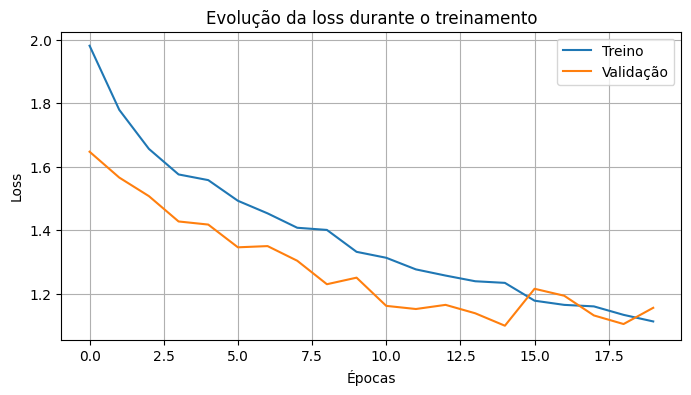

In [ ]:
# Gráfico da loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Evolução da loss durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

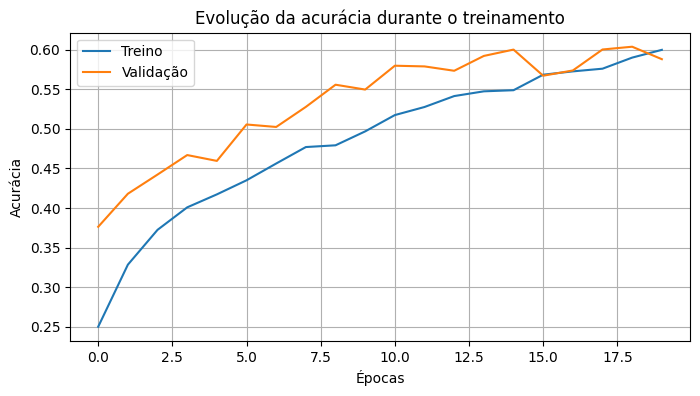

In [ ]:
# Gráfico da acurácia
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Evolução da acurácia durante o treinamento')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

## <font color='blue'>Análise dos resultados</font>

A loss de treino e validação apresentam comportamento semelhante, com tendência de queda ao longo das épocas, indicando aprendizado eficiente e ausência de overfitting significativo.

A acurácia aumenta de forma consistente tanto no treino quanto na validação, com curvas próximas entre si, demonstrando boa capacidade de generalização do modelo.

De modo geral, o modelo apresenta desempenho estável e confiável para a tarefa de classificação de imagens.

## <font color='blue'>Matriz de confusão</font>

A matriz de confusão mostra como o modelo distribuiu seus acertos e erros
entre as diferentes classes.

Os rótulos estão em português, facilitando a interpretação.

250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


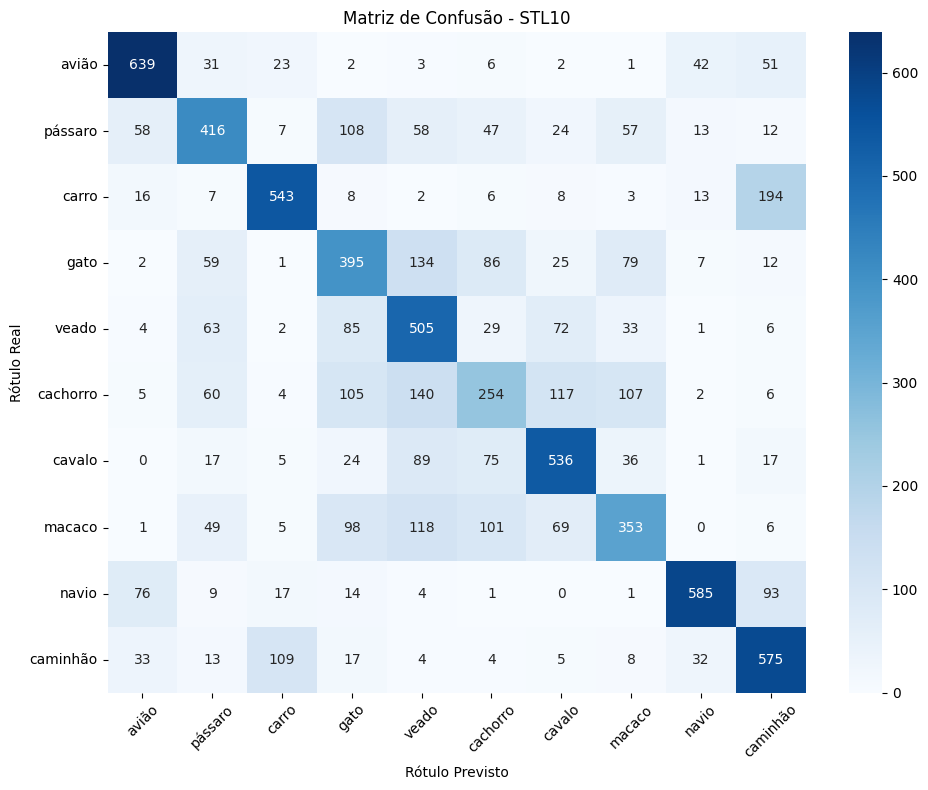

In [ ]:
# Faz previsões no conjunto de teste
y_pred = modelo_lia.predict(ds_teste)
y_pred_classes = np.argmax(y_pred, axis=1)

# Obtém os rótulos reais
y_true = np.concatenate([labels.numpy() for _, labels in ds_teste], axis=0)

# Matriz de confusão com TensorFlow (sem sklearn)
cm = tf.math.confusion_matrix(y_true, y_pred_classes).numpy()

# Exibe a matriz de confusão com nomes traduzidos
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes,
            yticklabels=nomes_classes)

plt.title('Matriz de Confusão - STL10')
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Real')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## <font color='blue'>Deploy do modelo</font>

### Entrada de nova imagem para predição

**Nesta etapa, o usuário pode escolher entre duas formas de fornecer a imagem:**
- upload direto do computador local
- link de uma imagem disponível na internet

**Independentemente da origem, a imagem será:**
- convertida para RGB
- redimensionada para 96x96 pixels
- normalizada para o intervalo de 0 a 1

Depois disso, o modelo fará a classificação da imagem.

## <font color='blue'>Opção 1: Upload de imagem</font>

In [ ]:
# Faz upload de uma imagem do computador
uploaded = files.upload()

Saving image.jpg to image.jpg


In [ ]:
# Obtém o nome do arquivo enviado
nome_arquivo = list(uploaded.keys())[0]

# Carrega a imagem
nova_imagem = Image.open(nome_arquivo).convert("RGB")

In [ ]:
# Dimensões da imagem (em pixels)
nova_imagem.size

(474, 379)

In [ ]:
# Obtém largura e altura da imagem
largura = nova_imagem.width
altura = nova_imagem.height

print("A largura da imagem é: ", largura)
print("A altura da imagem é: ", altura)

A largura da imagem é:  474
A altura da imagem é:  379


In [ ]:
# Redimensiona para 96x96 pixels (padrão do STL10)
nova_imagem = nova_imagem.resize((96, 96))

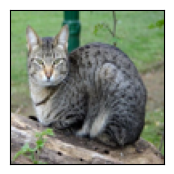

In [ ]:
# Exibe a imagem
plt.figure(figsize=(2, 2))
plt.imshow(nova_imagem)
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
# Converte a imagem para array NumPy e normaliza
nova_imagem_array = np.array(nova_imagem) / 255.0

In [ ]:
# Expande a dimensão para o formato (1, 96, 96, 3)
nova_imagem_array = np.expand_dims(nova_imagem_array, axis=0)

In [ ]:
# Faz a previsão
previsoes = modelo_lia.predict(nova_imagem_array)

print(previsoes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 667ms/step
[[1.7391676e-04 1.0954340e-01 2.8733700e-04 6.7345810e-01 1.0383612e-01
  5.7559699e-02 1.3740826e-02 3.8110435e-02 9.0187637e-04 2.3883572e-03]]


In [ ]:
# Obtém a classe com maior probabilidade
classe_prevista = np.argmax(previsoes)
nome_classe_prevista = nomes_classes[classe_prevista]

print("A nova imagem foi classificada como:", nome_classe_prevista)

A nova imagem foi classificada como: gato


## <font color='blue'>Opção 2: Link imagem web</font>

In [ ]:
def carregar_imagem_url():
    try:
        url = input("Cole a URL da imagem: ").strip()
        resposta = requests.get(url, stream=True)
        resposta.raise_for_status()
        imagem = Image.open(BytesIO(resposta.content)).convert("RGB")
        return imagem

    except requests.exceptions.MissingSchema:
        raise Exception("URL inválida. Inclua http:// ou https://")

    except requests.exceptions.ConnectionError:
        raise Exception("Erro de conexão. Verifique a internet ou a URL.")

    except requests.exceptions.HTTPError:
        raise Exception("Não foi possível acessar a imagem pela URL.")

    except IOError:
        raise Exception("O conteúdo informado não é uma imagem válida.")

    except Exception as e:
        raise Exception(f"Erro inesperado: {e}")

In [ ]:
try:
    nova_imagem = carregar_imagem_url()
    print("Imagem carregada com sucesso!")
except Exception as e:
    print("Erro ao carregar imagem pela URL:", e)

Cole a URL da imagem: https://www.mundoecologia.com.br/wp-content/uploads/2019/10/Fotos-de-Cavalo-Puro-Sangue-Lusitano-1.jpg
Imagem carregada com sucesso!


In [ ]:
# Dimensões da imagem (em pixels)
nova_imagem.size

(1417, 1019)

In [ ]:
# Obtém largura e altura da imagem
largura = nova_imagem.width
altura = nova_imagem.height

print("A largura da imagem é: ", largura)
print("A altura da imagem é: ", altura)

A largura da imagem é:  1417
A altura da imagem é:  1019


In [ ]:
# Redimensiona para 96x96 pixels
nova_imagem = nova_imagem.resize((96, 96))

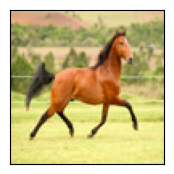

In [ ]:
# Exibe a imagem
plt.figure(figsize=(2, 2))
plt.imshow(nova_imagem)
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
# Converte a imagem para array NumPy e normaliza
nova_imagem_array = np.array(nova_imagem) / 255.0

In [ ]:
# Expande a dimensão para o formato (1, 96, 96, 3)
nova_imagem_array = np.expand_dims(nova_imagem_array, axis=0)

In [ ]:
# Faz a previsão
previsoes = modelo_lia.predict(nova_imagem_array)

print(previsoes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[2.9299579e-06 3.5170279e-03 5.7754290e-09 6.5520006e-05 5.3380185e-01
  1.3839476e-02 4.4855535e-01 2.1713834e-04 4.2146402e-09 6.8131709e-07]]


In [ ]:
# Obtém a classe com maior probabilidade
classe_prevista = np.argmax(previsoes)
nome_classe_prevista = nomes_classes[classe_prevista]

print("A nova imagem foi classificada como:", nome_classe_prevista)

A nova imagem foi classificada como: veado


## <font color='blue'>Conclusão</font>

Neste projeto, aplicamos um pipeline completo de classificação de imagens com o dataset STL10, incluindo:

- carregamento e exploração dos dados
- tradução das classes para português brasileiro
- pré-processamento das imagens
- construção de uma rede neural convolucional
- treinamento com EarlyStopping
- avaliação do modelo
- matriz de confusão sem uso de sklearn
- predição com imagens locais e imagens da web

A tradução das classes torna o projeto mais acessível e didático, enquanto o EarlyStopping melhora a eficiência do treinamento.